# Crypto stat-arb exploration

Hourly FTX data: `coin_all_prices_full.csv` (prices) and `coin_universe_150K_40.csv`
(the top-40 universe by market cap at each hour).

Pipeline: prices -> returns -> standardized returns -> correlation of the top-40 ->
eigenportfolios -> per-token residual -> AR(1)/OU fit -> trading signal.

The **BTC trace** at the bottom walks one token through every step.


## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WHEN, WINDOW = '2021-06-01 12:00', 240   # estimation window end and length (hours)
AR_WINDOW = 20                          # rolling window for the AR(1)/OU fit (hours)


## Data

In [3]:
def load(path):
    frame = pd.read_csv(path)
    frame['startTime'] = pd.to_datetime(frame['startTime'], utc=True)
    return frame.set_index('startTime').drop(columns='time').sort_index()


prices = load('data/coin_all_prices_full.csv')

# Hourly top-40 universe: rows = hour, cols = rank 0..39, values = ticker.
universe = load('data/coin_universe_150K_40.csv')
universe.columns = universe.columns.astype(int)

# Unlisted coins are logged as 0.0 in the price file, which would blow up
# pct_change, so zeros become NaN first.
raw_returns = prices.replace(0, np.nan).pct_change()

prices.shape, universe.shape


((14015, 125), (14015, 40))

## Standardization

In [4]:
def standardize_returns(returns, ddof=1):
    """Standardize returns column-wise over the estimation window.

    For each asset i:
        Rbar_i   = (1/T) * sum_t R_i(t)
        sigbar_i = sqrt( (1/(T-1)) * sum_t (R_i(t) - Rbar_i)^2 )
        Y_i(t)   = (R_i(t) - Rbar_i) / sigbar_i

    Parameters
    ----------
    returns : pd.DataFrame (rows = time, cols = assets) or pd.Series
    ddof : int, 1 for the sample volatility above (0 for the population one)

    Returns
    -------
    Same shape as `returns`, with mean 0 and unit volatility per column.
    Columns with zero (or undefined) volatility are returned as NaN.
    """
    mu = returns.mean(axis=0)
    sigma = returns.std(axis=0, ddof=ddof)
    sigma = sigma.replace(0, np.nan) if hasattr(sigma, "replace") else (np.nan if sigma == 0 else sigma)
    return (returns - mu) / sigma


In [5]:
returns = standardize_returns(raw_returns)
returns.head()


,1INCH,AAVE,AGLD,ALCX,ALGO,ALICE,ALPHA,AMPL,APE,ASD,...,TRU,TRX,TRYB,UNI,WAVES,XAUT,XRP,YFI,YFII,ZRX
startTime,,,,,,,,,,,,,,,,,,,,,
2021-02-19 05:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-19 06:00:00+00:00,0.681628,0.169676,NaN,NaN,NaN,NaN,0.856016,1.490615,NaN,-2.916258,...,1.819702,5.036795,-0.375173,-0.421331,2.449048,-0.025004,0.320931,0.079079,0.260748,NaN
2021-02-19 07:00:00+00:00,0.412510,0.754322,NaN,NaN,NaN,NaN,-0.802091,1.268092,NaN,1.160074,...,0.417459,0.814098,0.434188,0.634273,0.457897,0.055657,0.904849,0.619556,0.157464,NaN
2021-02-19 08:00:00+00:00,0.060482,1.165497,NaN,NaN,NaN,NaN,0.000667,-1.448054,NaN,1.197060,...,0.583120,3.255671,0.018861,-0.767360,1.019719,-0.697111,0.536299,-0.168393,0.140037,NaN
2021-02-19 09:00:00+00:00,-0.276355,-0.874079,NaN,NaN,NaN,NaN,0.392927,-0.187223,NaN,0.722340,...,-1.927607,-1.516544,0.848348,0.625093,1.234204,0.001882,-0.225022,-0.126149,-0.891571,NaN


## Universe at a given hour

In [6]:
def top_universe(when, values=None, dropna=True):
    """Ranked universe at a given hour.

    Parameters
    ----------
    when : anything pd.Timestamp accepts, e.g. '2021-06-01 12:00' or
           '2021-06-01T12:00:00+00:00'. Non-exact times snap back to the most
           recent hour on or before `when`.
    values : optional DataFrame indexed like df (e.g. prices or standardized
             returns) to pull each token's value at that hour alongside its rank.
    dropna : drop ranks with no token listed for that hour.

    Returns
    -------
    Series of tickers indexed by rank, or a DataFrame with a 'value' column
    when `values` is given.
    """
    ts = pd.Timestamp(when)
    if ts.tz is None:
        ts = ts.tz_localize('UTC')
    stamp = universe.index.asof(ts)
    if pd.isna(stamp):
        raise KeyError(f'{ts} is before the universe starts ({universe.index[0]})')

    row = universe.loc[stamp]
    if dropna:
        row = row.dropna()
    row = row.rename('token').rename_axis('rank')

    if values is None:
        return row

    out = row.to_frame()
    out['value'] = [values.at[stamp, t] if t in values.columns else np.nan
                    for t in out['token']]
    out.attrs['asof'] = stamp
    return out


In [7]:
top_universe(WHEN).head(10)


rank
0      BTC
1      BNB
2     DOGE
3      XRP
4      UNI
5     LINK
6      BCH
7      LTC
8    MATIC
9      SOL
Name: token, dtype: object

## Returns plot

In [8]:
def plot_returns(assets, start=None, end=None, kind='returns', standardize=False,
                 data=None, ax=None, **plot_kw):
    """Plot hourly returns for one or more assets.

    Parameters
    ----------
    assets : ticker or list of tickers, e.g. 'BTC' or ['BTC', 'ETH']
    start, end : optional time bounds, anything pd.Timestamp accepts
    kind : 'returns'     -> the return series itself
           'cumulative'  -> cumulative growth of 1 unit, (1 + R).cumprod()
    standardize : standardize each series over the plotted window first
                  (uses standardize_returns; ignored for kind='cumulative')
    data : returns frame to read from; defaults to the global `returns`
    ax : optional matplotlib Axes to draw on

    Returns
    -------
    The matplotlib Axes.
    """
    src = returns if data is None else data
    if isinstance(assets, str):
        assets = [assets]

    missing = [a for a in assets if a not in src.columns]
    if missing:
        raise KeyError(f'not in the returns frame: {missing}')

    lo = pd.Timestamp(start).tz_localize('UTC') if start is not None and pd.Timestamp(start).tz is None else start
    hi = pd.Timestamp(end).tz_localize('UTC') if end is not None and pd.Timestamp(end).tz is None else end
    y = src.loc[lo:hi, assets]

    if kind == 'cumulative':
        y = (1 + y.fillna(0)).cumprod()
        ylabel = 'cumulative growth of 1'
    elif kind == 'returns':
        if standardize:
            y = standardize_returns(y)
            ylabel = 'standardized return'
        else:
            ylabel = 'hourly return'
    else:
        raise ValueError("kind must be 'returns' or 'cumulative'")

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))
    y.plot(ax=ax, linewidth=0.8, **plot_kw)
    if kind == 'returns':
        ax.axhline(0, color='black', linewidth=0.6, alpha=0.5)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(', '.join(assets))
    ax.legend(loc='upper left', ncol=min(len(assets), 5), fontsize=8)
    return ax


## Correlation and eigen decomposition

In [9]:
def universe_corr(when, window=240, data=None, min_periods=None):
    """Correlation matrix of standardized returns for the top-40 universe at `when`.

    Uses the `window` hours ending at that timestamp (inclusive), standardizes each
    surviving token over that window, and correlates. Rows/cols are ordered by rank.
    Tokens with no data in the window are dropped.
    """
    src = raw_returns if data is None else data
    members = top_universe(when)
    stamp = members.name if members.name is not None else pd.Timestamp(when)
    stamp = universe.index.asof(pd.Timestamp(when).tz_localize('UTC')
                               if pd.Timestamp(when).tz is None else pd.Timestamp(when))

    cols = [t for t in members if t in src.columns]
    win = src.loc[:stamp, cols].tail(window)
    win = win.dropna(axis=1, how='all')
    Y = standardize_returns(win).dropna(axis=1, how='all')

    C = Y.corr(min_periods=min_periods or max(2, window // 2))
    C.attrs['asof'] = stamp
    C.attrs['window'] = window
    return C


In [10]:
def corr_eigen(C, top=None):
    """Eigenvalues/vectors of a correlation matrix, sorted descending."""
    C = C.dropna(axis=0, how='all').dropna(axis=1, how='all').fillna(0)
    vals, vecs = np.linalg.eigh(C.to_numpy())
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    if top is not None:
        vals, vecs = vals[:top], vecs[:, :top]
    idx = pd.RangeIndex(len(vals), name='component')
    return (pd.Series(vals, index=idx, name='eigenvalue'),
            pd.DataFrame(vecs, index=C.index, columns=idx))

In [11]:
def top_variance_eigen(C, threshold=0.90):
    """Leading eigenvectors whose cumulative variance share first reaches `threshold`.

    Returns (eigvals, eigvecs, explained) truncated to the smallest m with
    sum(lambda_1..lambda_m) / sum(lambda) >= threshold. `explained` is the
    per-component variance share of the kept components.
    """
    vals, vecs = corr_eigen(C)
    share = vals / vals.sum()
    m = int((share.cumsum() >= threshold).argmax()) + 1
    return vals.iloc[:m], vecs.iloc[:, :m], share.iloc[:m]


In [12]:
def top_eigen_variance(C):
    """Variance share explained by the largest eigenvalue alone.

    Returns (share, eigenvalue, eigenvector) â€” the eigenvector is a Series
    indexed by token.
    """
    vals, vecs = corr_eigen(C)
    return vals.iloc[0] / vals.sum(), vals.iloc[0], vecs.iloc[:, 0]


## Eigenportfolios

In [13]:
def eigen_portfolio(when, window=240, component=0, data=None, normalize=True):
    """Returns of the eigenportfolio built from `component` of the top-40 corr matrix.

    Avellaneda-Lee weights: Q_i = v_i / sigma_i, so the portfolio return is
    F(t) = sum_i Q_i * R_i(t) over the raw (unstandardized) returns.

    Returns (F, weights) where F is the portfolio return Series over the
    estimation window and weights a Series indexed by token.
    """
    src = raw_returns if data is None else data
    C = universe_corr(when, window=window, data=src)
    _, vecs = corr_eigen(C)
    v = vecs.iloc[:, component]

    stamp = C.attrs['asof']
    R = src.loc[:stamp, v.index].tail(window)
    sigma = R.std(ddof=1)

    w = v / sigma
    if w.sum() < 0:          # sign of an eigenvector is arbitrary; point it long
        w = -w
    if normalize:
        w = w / w.abs().sum()

    F = (R * w).sum(axis=1, min_count=1)
    F.attrs['asof'] = stamp
    return F, w


In [14]:
def plot_eigen_portfolio(when, window=240, component=0, kind='cumulative', ax=None):
    """Plot the eigenportfolio's returns over its estimation window."""
    F, w = eigen_portfolio(when, window=window, component=component)
    y = (1 + F.fillna(0)).cumprod() if kind == 'cumulative' else F
    label = 'cumulative growth of 1' if kind == 'cumulative' else 'hourly return'

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))
    y.plot(ax=ax, linewidth=1.0)
    if kind != 'cumulative':
        ax.axhline(0, color='black', linewidth=0.6, alpha=0.5)
    ax.set_xlabel('')
    ax.set_ylabel(label)
    ax.set_title(f'eigenportfolio {component} as of {F.attrs["asof"]:%Y-%m-%d %H:%M} '
                 f'({window}h window)')
    return ax


## Token vs eigenportfolio

In [15]:
def plot_vs_eigen(when, assets=('BTC', 'ETH'), window=240, component=0,
                  kind='cumulative', ax=None):
    """Standardized returns of `assets` and the eigenportfolio on one axis.

    Everything is standardized over the same estimation window before plotting,
    so the lines are directly comparable. kind='cumulative' compounds those
    standardized series; kind='returns' plots them straight.
    """
    F, _ = eigen_portfolio(when, window=window, component=component)
    stamp = F.attrs['asof']

    R = raw_returns.loc[:stamp, list(assets)].tail(window)
    panel = R.copy()
    panel[f'eigen{component}'] = F
    Y = standardize_returns(panel)

    y = (1 + Y.fillna(0)).cumprod() if kind == 'cumulative' else Y
    label = 'cumulative (standardized)' if kind == 'cumulative' else 'standardized return'

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))
    y.plot(ax=ax, linewidth=1.0)
    if kind != 'cumulative':
        ax.axhline(0, color='black', linewidth=0.6, alpha=0.5)
    ax.set_xlabel('')
    ax.set_ylabel(label)
    ax.set_title(f'{", ".join(assets)} vs eigenportfolio {component} '
                 f'as of {stamp:%Y-%m-%d %H:%M} ({window}h)')
    ax.legend(loc='upper left', fontsize=8)
    return ax


In [16]:
def plot_divergence(when, asset='BTC', window=240, component=0, threshold=1.5, ax=None):
    """Standardized returns of one token vs the eigenportfolio, with the token
    line drawn red wherever it pulls away (spread beyond `threshold` std devs)."""
    F, _ = eigen_portfolio(when, window=window, component=component)
    stamp = F.attrs['asof']

    panel = raw_returns.loc[:stamp, [asset]].tail(window)
    eig = f'eigen{component}'
    panel[eig] = F
    Y = standardize_returns(panel)

    spread = Y[asset] - Y[eig]
    mask = spread.abs() >= threshold * spread.std(ddof=1)
    mask = mask | mask.shift(-1, fill_value=False)   # keep the red segments joined

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))
    ax.plot(Y.index, Y[eig], color='tab:blue', linewidth=1.0, label=eig)
    ax.plot(Y.index, Y[asset], color='0.4', linewidth=1.0, label=asset)
    ax.plot(Y.index, Y[asset].where(mask), color='red', linewidth=2.0, label='separation')
    ax.axhline(0, color='black', linewidth=0.6, alpha=0.5)
    ax.set_xlabel('')
    ax.set_ylabel('standardized return')
    ax.set_title(f'{asset} vs eigenportfolio {component} '
                 f'as of {stamp:%Y-%m-%d %H:%M} ({window}h)')
    ax.legend(loc='upper left', fontsize=8)
    return ax


In [17]:
def divergence_distribution(when, asset='BTC', window=240, component=0,
                            bins=50, plot=True, ax=None):
    """Distribution of a token's divergence from the eigenportfolio.

    Divergence is the spread of standardized returns, spread(t) = Y_asset(t) -
    Y_eigen(t), over the estimation window ending at `when`.

    Returns (spread, stats) where stats holds mean/std/skew/kurtosis, the
    quantiles, and the share of bars beyond 1/2/3 std devs. Draws a histogram
    unless plot=False.
    """
    F, _ = eigen_portfolio(when, window=window, component=component)
    stamp = F.attrs['asof']

    panel = raw_returns.loc[:stamp, [asset]].tail(window)
    eig = f'eigen{component}'
    panel[eig] = F
    Y = standardize_returns(panel)

    spread = (Y[asset] - Y[eig]).dropna().rename(f'{asset} - {eig}')
    s = spread.std(ddof=1)
    z = spread.abs() / s

    stats = pd.Series({
        'n': len(spread),
        'mean': spread.mean(),
        'std': s,
        'skew': spread.skew(),
        'kurtosis': spread.kurtosis(),
        'min': spread.min(),
        'q05': spread.quantile(0.05),
        'q25': spread.quantile(0.25),
        'median': spread.median(),
        'q75': spread.quantile(0.75),
        'q95': spread.quantile(0.95),
        'max': spread.max(),
        'pct_beyond_1sd': (z >= 1).mean(),
        'pct_beyond_2sd': (z >= 2).mean(),
        'pct_beyond_3sd': (z >= 3).mean(),
    }, name=spread.name)

    if plot:
        if ax is None:
            _, ax = plt.subplots(figsize=(8, 4))
        ax.hist(spread, bins=bins, color='0.6', edgecolor='white')
        for k, style in ((1, ':'), (2, '--')):
            for sign in (-1, 1):
                ax.axvline(sign * k * s, color='red', linestyle=style, linewidth=1,
                           label=f'{k} sd' if sign > 0 else None)
        ax.axvline(spread.mean(), color='tab:blue', linewidth=1, label='mean')
        ax.set_xlabel('divergence (standardized return spread)')
        ax.set_ylabel('bars')
        ax.set_title(f'{asset} divergence from eigenportfolio {component} '
                     f'as of {stamp:%Y-%m-%d %H:%M} ({window}h)')
        ax.legend(fontsize=8)

    return spread, stats


## Residual and AR(1) / OU fit

In [18]:
def token_residual(token, when, window=240, component=0):
    """Residual of one token against the eigenportfolio, over the window ending at `when`.

    Regress the token's standardized returns on the eigenportfolio's:
        Y(t) = a + b * F(t) + eps(t)
    Returns (eps, cumulative eps, b).
    """
    F, _ = eigen_portfolio(when, window=window, component=component)
    stamp = F.attrs['asof']

    Y = standardize_returns(raw_returns.loc[:stamp, token].tail(window))
    Yf = standardize_returns(F)

    both = pd.concat([Y.rename('y'), Yf.rename('f')], axis=1).dropna()
    b, a = np.polyfit(both['f'], both['y'], 1)
    eps = (both['y'] - (a + b * both['f'])).rename(token)
    return eps, eps.cumsum(), b


def plot_token_residual(token, when, window=240, component=0):
    """Residual returns on top, cumulative residual below."""
    eps, cum, b = token_residual(token, when, window=window, component=component)

    fig, (top, bottom) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    top.plot(eps.index, eps, linewidth=0.9, color='tab:blue')
    top.axhline(0, color='black', linewidth=0.6, alpha=0.5)
    top.set_ylabel('residual return')
    top.set_title(f'{token} residual vs eigenportfolio {component} '
                  f'({window}h to {eps.index[-1]:%Y-%m-%d %H:%M}, beta={b:.2f})')

    bottom.plot(cum.index, cum, linewidth=1.1, color='tab:purple')
    bottom.axhline(0, color='black', linewidth=0.6, alpha=0.5)
    bottom.set_ylabel('cumulative residual')
    return top, bottom


In [19]:
def ar1_residual(token, when, window=240, ar_window=20, component=0,
                 bars_per_year=24 * 365):
    """AR(1) fit of the cumulative residual (Avellaneda-Lee OU estimation).

        X(n+1) = a + b * X(n) + zeta(n+1)

    The residual itself is built on the `window`-hour estimation window, but the
    AR(1) is fitted on a rolling `ar_window` (default 20h) of X ending at `when`,
    so b tracks the recent reversion speed instead of averaging over the whole
    window. Pass ar_window=None to fit on all of X.

    From the fit: m = a / (1 - b) is the equilibrium level, kappa = -log(b) * bars_per_year
    the mean-reversion speed, tau = 1 / kappa the reversion time (in years), and
        sigma_eq = sqrt( var(zeta) / (1 - b^2) )
    the equilibrium spread, giving the s-score (X - m) / sigma_eq.

    Returns (X, fit) with fit a Series of a, b, m, kappa, tau_days, sigma_eq,
    s_score; X is the full cumulative residual, fit.attrs['ar_window'] the bars used.
    """
    _, X, _ = token_residual(token, when, window=window, component=component)
    Xf = X if ar_window is None else X.tail(ar_window)
    if len(Xf) < 3:
        raise ValueError(f'ar_window={ar_window} leaves {len(Xf)} bars to fit')

    x0, x1 = Xf.iloc[:-1].to_numpy(), Xf.iloc[1:].to_numpy()
    b, a = np.polyfit(x0, x1, 1)
    zeta = x1 - (a + b * x0)

    m = a / (1 - b) if b != 1 else np.nan
    kappa = -np.log(b) * bars_per_year if 0 < b < 1 else np.nan
    sigma_eq = np.sqrt(zeta.var(ddof=1) / (1 - b ** 2)) if abs(b) < 1 else np.nan

    fit = pd.Series({'a': a, 'b': b, 'm': m, 'kappa': kappa,
                     'tau_days': 365 / kappa if kappa and kappa > 0 else np.nan,
                     'sigma_eq': sigma_eq,
                     's_score': (X.iloc[-1] - m) / sigma_eq if sigma_eq else np.nan},
                    name=token)
    fit.attrs['ar_window'] = len(Xf)
    fit.attrs['asof'] = X.index[-1]
    return X, fit


def rolling_ar1(token, when, window=240, ar_window=20, component=0,
                bars_per_year=24 * 365):
    """AR(1) fit rolled hour by hour across the estimation window.

    The residual is built once on the `window` hours ending at `when`; the AR(1)
    is then refitted on every trailing `ar_window` slice of X, giving a frame of
    a, b, m, kappa, tau_days, sigma_eq and s_score indexed by the hour each
    window ends on.
    """
    _, X, _ = token_residual(token, when, window=window, component=component)

    rows = {}
    for end in range(ar_window, len(X) + 1):
        Xf = X.iloc[end - ar_window:end]
        x0, x1 = Xf.iloc[:-1].to_numpy(), Xf.iloc[1:].to_numpy()
        b, a = np.polyfit(x0, x1, 1)
        zeta = x1 - (a + b * x0)
        m = a / (1 - b) if b != 1 else np.nan
        kappa = -np.log(b) * bars_per_year if 0 < b < 1 else np.nan
        sigma_eq = np.sqrt(zeta.var(ddof=1) / (1 - b ** 2)) if abs(b) < 1 else np.nan
        rows[Xf.index[-1]] = {
            'a': a, 'b': b, 'm': m, 'kappa': kappa,
            'tau_days': 365 / kappa if kappa and kappa > 0 else np.nan,
            'sigma_eq': sigma_eq,
            's_score': (Xf.iloc[-1] - m) / sigma_eq if sigma_eq else np.nan,
        }

    out = pd.DataFrame.from_dict(rows, orient='index').rename_axis('startTime')
    out.attrs['ar_window'] = ar_window
    return out


def plot_ar1(token, when, window=240, ar_window=20, component=0):
    """Cumulative residual X(t) with the AR(1) equilibrium m, plus the X(n) -> X(n+1)
    scatter carrying the fitted line a + b*X(n). Only the trailing `ar_window`
    hours (shaded on the left panel) feed the fit."""
    X, fit = ar1_residual(token, when, window=window, ar_window=ar_window,
                          component=component)
    a, b, m, sigma_eq = fit['a'], fit['b'], fit['m'], fit['sigma_eq']
    Xf = X.tail(fit.attrs['ar_window'])

    fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4.5),
                                      gridspec_kw={'width_ratios': [2, 1]})

    left.plot(X.index, X, linewidth=1.0, color='0.7', label='X(t)')
    left.plot(Xf.index, Xf, linewidth=1.4, color='tab:purple',
              label=f'AR(1) window ({fit.attrs["ar_window"]}h)')
    left.axvspan(Xf.index[0], Xf.index[-1], color='tab:purple', alpha=0.08)
    left.axhline(m, color='red', linewidth=1.2, label=f'm = {m:.3f}')
    if np.isfinite(sigma_eq):
        for sign in (-1, 1):
            left.axhline(m + sign * sigma_eq, color='red', linestyle='--',
                         linewidth=0.9,
                         label='m +/- sigma_eq' if sign > 0 else None)
    left.set_ylabel('cumulative residual X(t)')
    left.set_title(f'{token}: a={a:.4f}, b={b:.3f}, m={m:.3f}, '
                   f's-score={fit["s_score"]:.2f}')
    left.legend(loc='upper left', fontsize=8)

    x0, x1 = Xf.iloc[:-1], Xf.iloc[1:]
    right.scatter(x0, x1, s=8, color='0.6')
    grid = np.linspace(x0.min(), x0.max(), 100)
    right.plot(grid, a + b * grid, color='red', linewidth=1.2,
               label=f'X(n+1) = {a:.4f} + {b:.3f} X(n)')
    right.plot(grid, grid, color='black', linewidth=0.7, alpha=0.5, label='45 deg')
    right.axvline(m, color='red', linestyle=':', linewidth=1)
    right.set_xlabel('X(n)')
    right.set_ylabel('X(n+1)')
    right.set_title(f'AR(1) fit ({fit.attrs["ar_window"]}h)')
    right.legend(fontsize=8)
    fig.tight_layout()
    return left, right


def plot_rolling_ar1(token, when, window=240, ar_window=20, component=0,
                     bands=True, ax=None):
    """Cumulative residual X(t) with the AR(1) equilibrium m re-estimated every hour.

    m is not a constant here: each point is the equilibrium a / (1 - b) implied by
    the AR(1) fitted on the `ar_window` hours ending at that bar, so the red line
    is the level X is being pulled toward as of each hour. The shaded band is
    m +/- sigma_eq from the same fit. The lower panel is the s-score that band
    produces, (X - m) / sigma_eq.
    """
    _, X, _ = token_residual(token, when, window=window, component=component)
    roll = rolling_ar1(token, when, window=window, ar_window=ar_window,
                       component=component)

    fig, (top, bottom) = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True,
                                      gridspec_kw={'height_ratios': [2, 1]})

    top.plot(X.index, X, linewidth=1.0, color='tab:purple', label='X(t)')
    top.plot(roll.index, roll['m'], linewidth=1.3, color='red',
             label=f'm (rolling {ar_window}h)')
    if bands:
        top.fill_between(roll.index, roll['m'] - roll['sigma_eq'],
                         roll['m'] + roll['sigma_eq'], color='red', alpha=0.12,
                         linewidth=0, label='m +/- sigma_eq')
    top.axhline(0, color='black', linewidth=0.6, alpha=0.5)
    top.set_ylabel('cumulative residual X(t)')
    top.set_title(f'{token}: X(t) vs rolling AR(1) equilibrium '
                  f'({ar_window}h fit, {window}h residual to '
                  f'{X.index[-1]:%Y-%m-%d %H:%M})')
    top.legend(loc='upper left', fontsize=8)

    bottom.plot(roll.index, roll['s_score'], linewidth=1.0, color='tab:blue')
    bottom.axhline(0, color='black', linewidth=0.6, alpha=0.5)
    for level in (-2, 2):
        bottom.axhline(level, color='red', linestyle='--', linewidth=0.8)
    bottom.set_ylabel('s-score')
    bottom.set_xlabel('')
    fig.tight_layout()
    return top, bottom


---
# BTC trace

Every step above applied to one token, on the window ending at `WHEN`.


In [20]:
ASSET = 'BTC'


### 1. Where does BTC sit in the universe?

In [21]:
members = top_universe(WHEN)
print(f'{ASSET} rank at {WHEN}:',
      members[members == ASSET].index.tolist() or 'not in the top 40')
members.head(10).tolist()


BTC rank at 2021-06-01 12:00: [0]


['BTC', 'BNB', 'DOGE', 'XRP', 'UNI', 'LINK', 'BCH', 'LTC', 'MATIC', 'SOL']

### 2. Raw vs standardized returns

In [22]:
btc_raw = raw_returns.loc[:WHEN, ASSET].tail(WINDOW)
btc_std = standardize_returns(btc_raw)
pd.DataFrame({'raw': btc_raw.describe(), 'standardized': btc_std.describe()})


,raw,standardized
count,240.000000,2.400000e+02
mean,-0.000094,1.480297e-17
std,0.012958,1.000000e+00
min,-0.042553,-3.276748e+00
25%,-0.008198,-6.254733e-01
50%,-0.000494,-3.086411e-02
75%,0.007314,5.717102e-01
max,0.044359,3.430608e+00


<Axes: title={'center': 'BTC'}, ylabel='standardized return'>

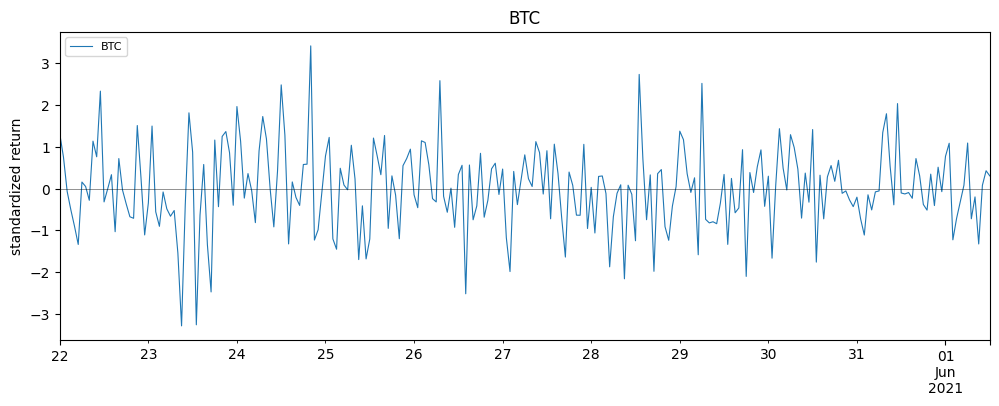

In [23]:
plot_returns(ASSET, start='2021-05-22', end=WHEN, standardize=True)


### 3. Correlation matrix and its spectrum

In [24]:
C = universe_corr(WHEN, window=WINDOW)
vals, vecs = corr_eigen(C)
share1, lam1, v1 = top_eigen_variance(C)
print(f'PC1 explains {share1:.1%} (lambda = {lam1:.2f}); '
      f'{len(top_variance_eigen(C, 0.90)[0])} components reach 90%')
v1.sort_values(ascending=False).head(10)


PC1 explains 75.1% (lambda = 30.05); 12 components reach 90%


FTT     0.176151
TRX     0.175809
BNB     0.173627
SRM     0.173505
UNI     0.171731
LTC     0.171346
AAVE    0.171191
SNX     0.170210
LINK    0.169881
COMP    0.169408
Name: 0, dtype: float64

### 4. The eigenportfolio and BTC against it

In [25]:
F, w = eigen_portfolio(WHEN, window=WINDOW, component=0)
print(f'{ASSET} weight in the eigenportfolio: {w.get(ASSET, float("nan")):.4f}')
w.sort_values(ascending=False).head(10)


BTC weight in the eigenportfolio: 0.0452


OXY     0.117791
BTC     0.045217
TRX     0.039817
FTT     0.034687
BCH     0.029186
DOGE    0.028620
LTC     0.028054
BNB     0.027852
CEL     0.027088
RAY     0.025820
dtype: float64

<Axes: title={'center': 'BTC vs eigenportfolio 0 as of 2021-06-01 12:00 (240h)'}, ylabel='standardized return'>

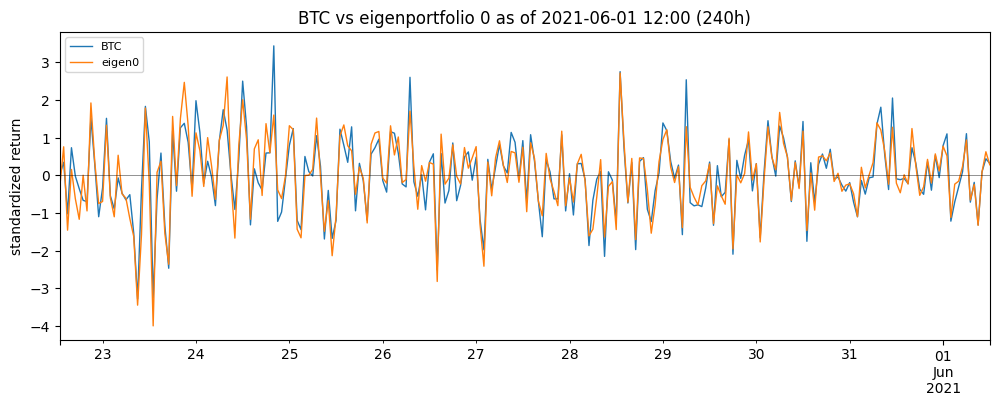

In [26]:
plot_vs_eigen(WHEN, [ASSET], window=WINDOW, kind='returns')


<Axes: title={'center': 'BTC vs eigenportfolio 0 as of 2021-06-01 12:00 (240h)'}, ylabel='standardized return'>

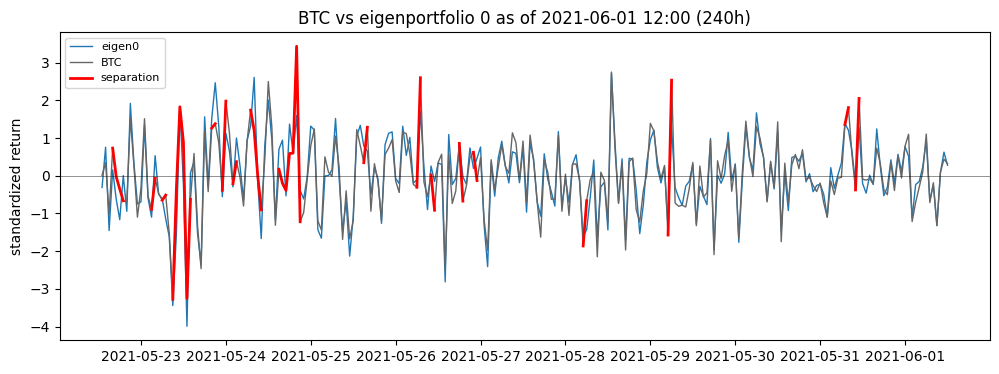

In [27]:
plot_divergence(WHEN, ASSET, window=WINDOW, threshold=1.5)


### 5. Divergence distribution

n                 2.400000e+02
mean              1.387779e-17
std               3.950189e-01
skew              4.491116e-01
kurtosis          2.678622e+00
min              -1.405261e+00
q05              -5.569116e-01
q25              -2.065109e-01
median           -2.451841e-03
q75               1.885376e-01
q95               6.336723e-01
max               1.833389e+00
pct_beyond_1sd    2.625000e-01
pct_beyond_2sd    4.583333e-02
pct_beyond_3sd    1.250000e-02
Name: BTC - eigen0, dtype: float64

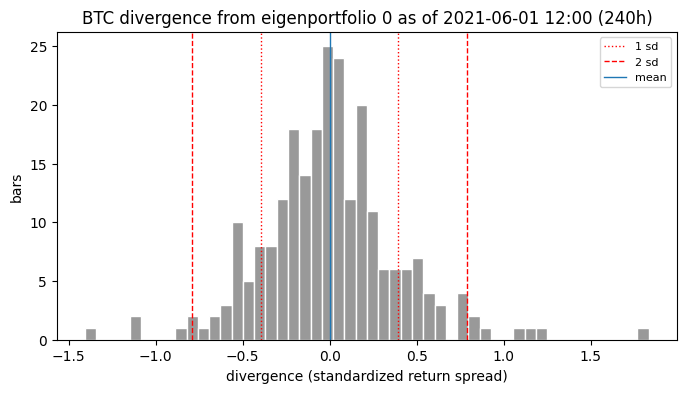

In [28]:
spread, stats = divergence_distribution(WHEN, ASSET, window=WINDOW)
stats


### 6. Residual, cumulative residual, AR(1)

(<Axes: title={'center': 'BTC residual vs eigenportfolio 0 (240h to 2021-06-01 12:00, beta=0.92)'}, ylabel='residual return'>,
 <Axes: ylabel='cumulative residual'>)

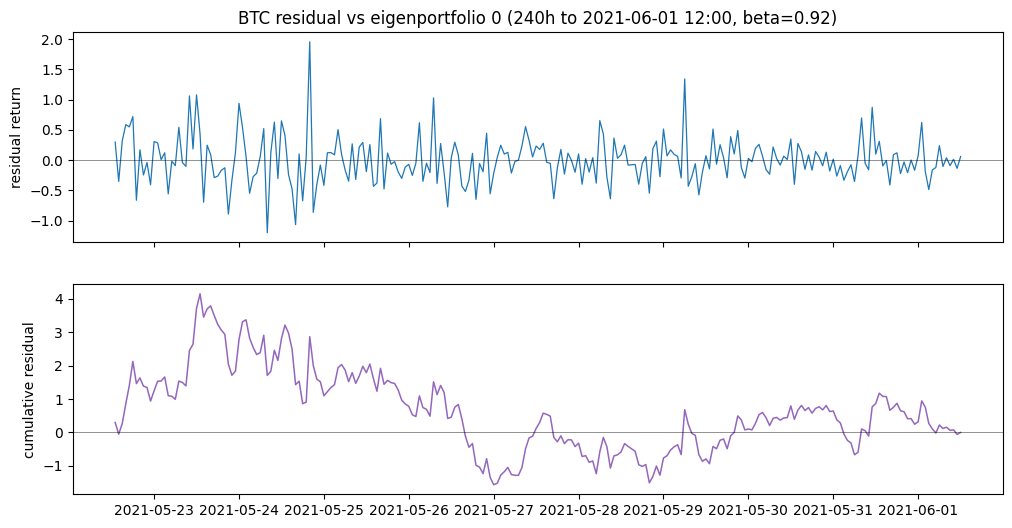

In [29]:
plot_token_residual(ASSET, WHEN, window=WINDOW)


a              0.059900
b              0.726875
m              0.219314
kappa       2794.450938
tau_days       0.130616
sigma_eq       0.303733
s_score       -0.722060
Name: BTC, dtype: float64

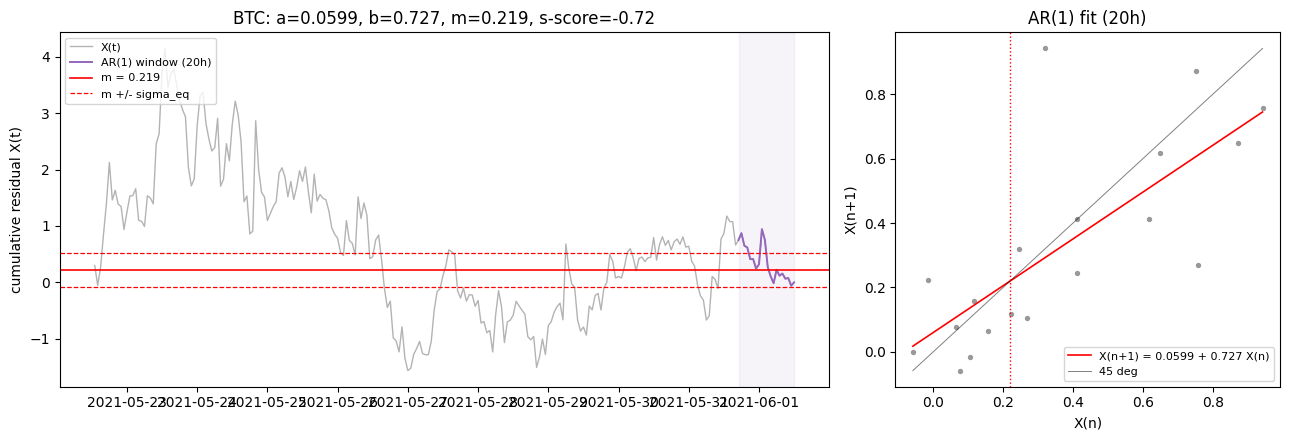

In [30]:
X, fit = ar1_residual(ASSET, WHEN, window=WINDOW, ar_window=AR_WINDOW)
plot_ar1(ASSET, WHEN, window=WINDOW, ar_window=AR_WINDOW)
fit


### 7. The moving equilibrium

Refitting the AR(1) on every trailing `AR_WINDOW`-hour slice turns `m` into a series: the level `X` is
being pulled toward as of each hour, with its own `sigma_eq` band and s-score.


(<Axes: title={'center': 'BTC: X(t) vs rolling AR(1) equilibrium (20h fit, 240h residual to 2021-06-01 12:00)'}, ylabel='cumulative residual X(t)'>,
 <Axes: ylabel='s-score'>)

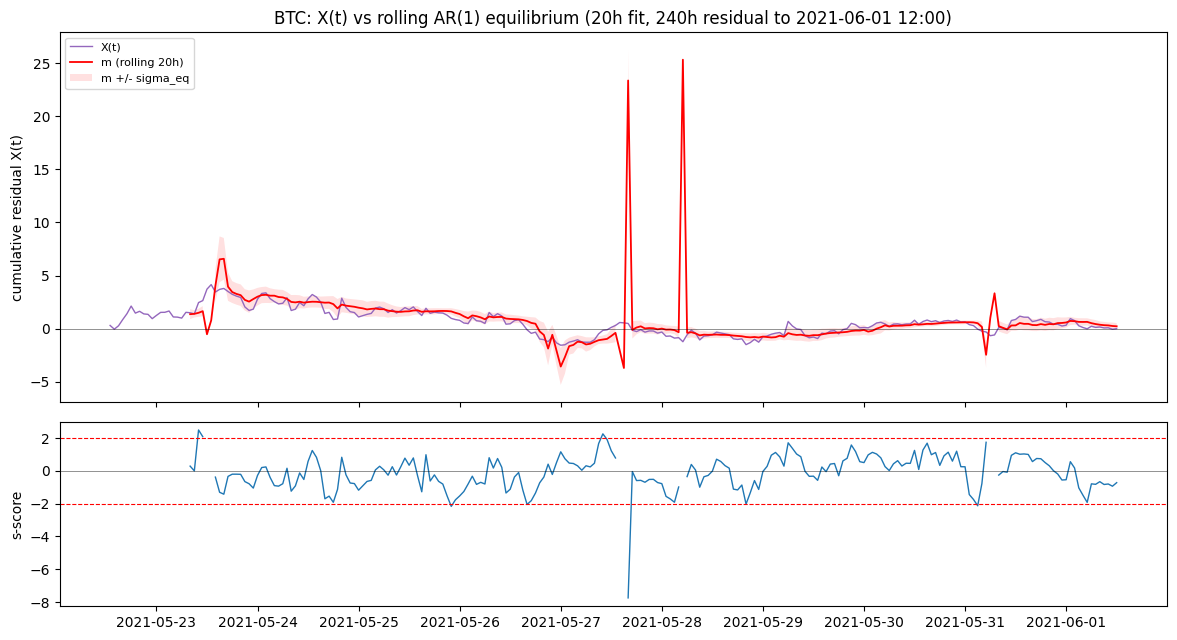

In [31]:
plot_rolling_ar1(ASSET, WHEN, window=WINDOW, ar_window=AR_WINDOW)


In [32]:
roll = rolling_ar1(ASSET, WHEN, window=WINDOW, ar_window=AR_WINDOW)
roll[['b', 'm', 'sigma_eq', 'tau_days', 's_score']].tail(10)


,b,m,sigma_eq,tau_days,s_score
startTime,,,,,
2021-06-01 03:00:00+00:00,0.585938,0.633827,0.352122,0.077948,-1.036954
2021-06-01 04:00:00+00:00,0.572849,0.628304,0.350968,0.074788,-1.489985
2021-06-01 05:00:00+00:00,0.548864,0.635213,0.338639,0.069456,-1.923923
2021-06-01 06:00:00+00:00,0.752938,0.513794,0.366860,0.146831,-0.793421
2021-06-01 07:00:00+00:00,0.770910,0.429116,0.378767,0.160144,-0.822885
2021-06-01 08:00:00+00:00,0.724884,0.366482,0.318230,0.129503,-0.661446
2021-06-01 09:00:00+00:00,0.709915,0.323686,0.311610,0.121615,-0.832558
2021-06-01 10:00:00+00:00,0.653811,0.303088,0.281314,0.098054,-0.802609
2021-06-01 11:00:00+00:00,0.755368,0.247074,0.326369,0.148518,-0.937649


`s_score = (X_last - m) / sigma_eq`: strongly positive means the token has run
ahead of the factor and is a short candidate, strongly negative the reverse.
